## 在flickr30K上的结果

In [1]:
from tqdm import tqdm
import json
import torch
from collections import Counter

In [2]:
model_name_list = ['align-base', 'clipseg-rd64-refined', 'clip-vit-base-patch32', 'groupvit-gcc-yfcc']
cfg = {
    'topk_num': 10,
}

In [3]:
flickr30k_test_data = json.load(open('data/flickr30k_test_data.json', 'r', encoding='utf-8'))
test_sen_to_ids = {}
for img_file, text_list in flickr30k_test_data.items():
    for text in text_list:
        test_sen_to_ids[text] = img_file[:-4]

In [4]:
def get_enhance_index(text, text_to_enhanced):
    return list(text_to_enhanced.keys()).index(text)

In [5]:
for topk_num in [1, 5, 10]:
    test_img_ids = json.load(open('data/test_img_ids.json', 'r', encoding='utf-8'))
    text_to_enhanced = json.load(open('data/text_to_enhanced_list.json', 'r', encoding='utf-8'))
    # topk_num = cfg['topk_num']

    for name in model_name_list:
        fload_recall_list = []
        image_features = torch.load('data/image_features_{}.pt'.format(name),
                                    map_location=torch.device('cpu'))
        image_features = torch.stack(image_features).view(1000, -1)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        text_features = torch.load('data/enhanced_text_features_{}.pt'.format(name),
                                   map_location=torch.device('cpu')) # list
        raw_text_features = torch.load('data/raw_text_features_{}.pt'.format(name),
                                       map_location=torch.device('cpu'))
        raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)


        recall_list = []
        for i, (text, true_id) in enumerate(test_sen_to_ids.items()):
            enhance_list = text_to_enhanced[text]
            # index = get_text_index(text, sub_test_sen_to_ids)
            enhance_i = get_enhance_index(text, text_to_enhanced)
            enhance_text_features = torch.cat([text_features[enhance_i], raw_text_features[i].view(1, -1)], 0)

            enhance_text_features /= enhance_text_features.norm(dim=-1, keepdim=True)
            similarity = (100.0 * enhance_text_features @ image_features.T).softmax(dim=-1)

            counter = Counter()
            for k in range(enhance_text_features.shape[0]):
                values, pre_indexes = similarity[k].topk(topk_num)
                pre_ids = [test_img_ids[j] for j in pre_indexes]
                counter.update(pre_ids)
            pre_ids = [img_id for (img_id, _) in counter.most_common(topk_num)]
            if true_id in pre_ids:
                r = 1
                recall_list.append(1)
            else:
                recall_list.append(0)
        recall = sum(recall_list) / len(recall_list)
        print('model [{model}], topK [K={topK}], recall [{recall}]'.format(
            model=name,
            topK = topk_num,
            recall=recall
        ))

KeyboardInterrupt: 

In [6]:
for topk_num in [1, 5, 10]:
    test_img_ids = json.load(open('data/test_img_ids.json', 'r', encoding='utf-8'))
    text_to_enhanced = json.load(open('data/text_to_enhanced_list.json', 'r', encoding='utf-8'))
    # topk_num = cfg['topk_num']

    for name in model_name_list:
        fload_recall_list = []
        image_features = torch.load('data/image_features_{}.pt'.format(name),
                                    map_location=torch.device('cpu'))
        image_features = torch.stack(image_features).view(1000, -1)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # text_features = torch.load('data/enhanced_text_features_{}.pt'.format(name),
        #                            map_location=torch.device('cpu')) # list
        raw_text_features = torch.load('data/raw_text_features_{}.pt'.format(name),
                                       map_location=torch.device('cpu'))
        raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)


        recall_list = []
        similarity = (100.0 * raw_text_features @ image_features.T).softmax(dim=-1)
        for i, (text, true_id) in enumerate(test_sen_to_ids.items()):
            # enhance_list = text_to_enhanced[text]
            # index = get_text_index(text, sub_test_sen_to_ids)
            # enhance_i = get_enhance_index(text, text_to_enhanced)
            # enhance_text_features = torch.cat([text_features[enhance_i], raw_text_features[i].view(1, -1)], 0)

            # enhance_text_features /= enhance_text_features.norm(dim=-1, keepdim=True)

            values, pre_indexes = similarity[i].topk(topk_num)
            pre_ids = [test_img_ids[j] for j in pre_indexes]
            if true_id in pre_ids:
                r = 1
                recall_list.append(1)
            else:
                recall_list.append(0)
        recall = sum(recall_list) / len(recall_list)
        print('model [{model}], topK [K={topK}], recall [{recall}]'.format(
            model=name,
            topK = topk_num,
            recall=recall
        ))

model [align-base], topK [K=1], recall [0.7391478295659132]
model [clipseg-rd64-refined], topK [K=1], recall [0.6197239447889578]
model [clip-vit-base-patch32], topK [K=1], recall [0.5865173034606921]
model [groupvit-gcc-yfcc], topK [K=1], recall [0.3634726945389078]
model [align-base], topK [K=5], recall [0.921384276855371]
model [clipseg-rd64-refined], topK [K=5], recall [0.8617723544708942]
model [clip-vit-base-patch32], topK [K=5], recall [0.8315663132626525]
model [groupvit-gcc-yfcc], topK [K=5], recall [0.6535307061412282]
model [align-base], topK [K=10], recall [0.956991398279656]
model [clipseg-rd64-refined], topK [K=10], recall [0.9149829965993198]
model [clip-vit-base-patch32], topK [K=10], recall [0.8975795159031806]
model [groupvit-gcc-yfcc], topK [K=10], recall [0.7677535507101421]


## 可视化

In [6]:
topk_num = 10
test_img_ids = json.load(open('data/test_img_ids.json', 'r', encoding='utf-8'))
text_to_enhanced = json.load(open('data/text_to_enhanced_list.json', 'r', encoding='utf-8'))
# topk_num = cfg['topk_num']

for name in model_name_list[:1]:
    fload_recall_list = []
    fload_text_to_sim = []
    image_features = torch.load('data/image_features_{}.pt'.format(name),
                                map_location=torch.device('cpu'))
    image_features = torch.stack(image_features).view(1000, -1)
    image_features /= image_features.norm(dim=-1, keepdim=True)

    text_features = torch.load('data/enhanced_text_features_{}.pt'.format(name),
                               map_location=torch.device('cpu')) # list
    raw_text_features = torch.load('data/raw_text_features_{}.pt'.format(name),
                                   map_location=torch.device('cpu'))
    raw_text_features /= raw_text_features.norm(dim=-1, keepdim=True)


    recall_list = []
    text_to_sim = {}
    for i, (text, true_id) in enumerate(test_sen_to_ids.items()):
        enhance_list = text_to_enhanced[text]
        # index = get_text_index(text, sub_test_sen_to_ids)
        enhance_i = get_enhance_index(text, text_to_enhanced)
        enhance_text_features = torch.cat([text_features[enhance_i], raw_text_features[i].view(1, -1)], 0)

        enhance_text_features /= enhance_text_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * enhance_text_features @ image_features.T).softmax(dim=-1)
        text_to_sim[text] = similarity
        counter = Counter()
        for k in range(enhance_text_features.shape[0]):
            values, pre_indexes = similarity[k].topk(topk_num)
            pre_ids = [test_img_ids[j] for j in pre_indexes]
            counter.update(pre_ids)
        pre_ids = [img_id for (img_id, _) in counter.most_common(topk_num)]
        if true_id in pre_ids:
            r = 1
            recall_list.append(1)
        else:
            recall_list.append(0)
    recall = sum(recall_list) / len(recall_list)
    fload_text_to_sim.append(text_to_sim)
    print('model [{model}], topK [K={topK}], recall [{recall}]'.format(
        model=name,
        topK = topk_num,
        recall=recall
    ))


model [align-base], topK [K=10], recall [0.960992198439688]


In [7]:
import json
import random
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from collections import Counter, defaultdict
import pandas as pd
import seaborn as sns
import torch
import matplotlib as mpl

In [8]:
flod_i = 0
index = 100

test_data = list(test_sen_to_ids.keys())
text_to_sim = fload_text_to_sim[flod_i]
text = test_data[index]
ture_ids = test_sen_to_ids[text]
enhance_list = text_to_enhanced[text]
len(enhance_list)

10

In [9]:
ture_ids, text

('1144865997',
 'A group of people standing on the lawn in front of a building .')

In [10]:
sim = text_to_sim[text]
raw_sim = sim[0] # 原query相似度

In [11]:
topK_img_index= torch.topk(raw_sim, 10)[1].tolist()
topK_img_ids = [test_img_ids[i] for i in topK_img_index]

In [12]:
topK_img_index

[827, 742, 824, 514, 490, 284, 130, 950, 302, 3]

In [13]:
topK_sim = sim[:, topK_img_index].softmax(dim=-1).tolist()
x_index = [i+'**' if i in ture_ids else i for i in topK_img_ids]

In [14]:
df = pd.DataFrame(columns=x_index, index=enhance_list + [text], data=topK_sim)

<AxesSubplot: >

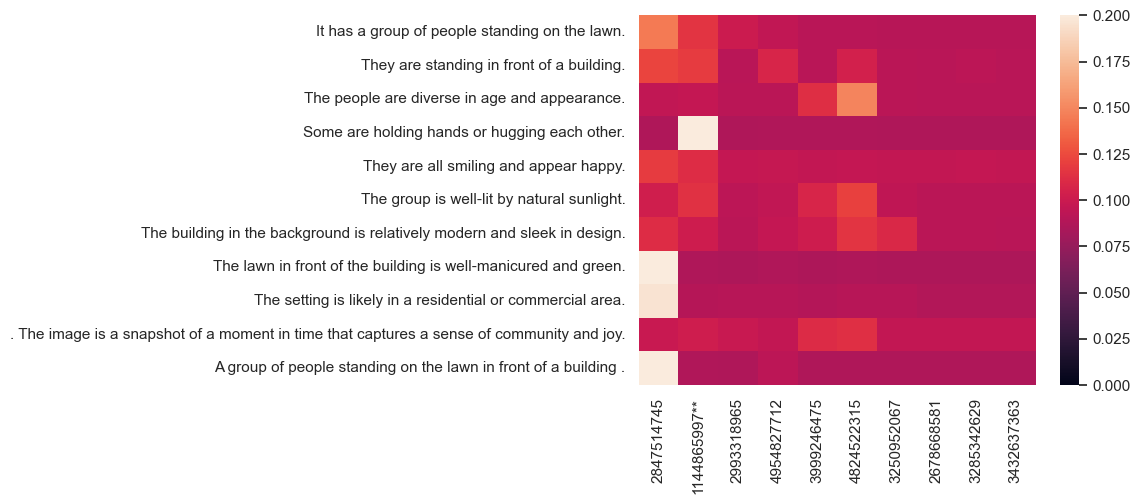

In [17]:
sns.set(font_scale=1)
sns.heatmap(data=df,vmin=0,vmax=0.2)

In [22]:
# 找到有正确图片的
flod_i = 0
test_data = list(test_sen_to_ids.keys())
text_to_sim = fload_text_to_sim[flod_i]
for j in range(len(test_data)):
    text = test_data[j]
    ture_ids = test_sen_to_ids[text]
    sim = text_to_sim[text]
    raw_sim = sim[0] # 原query相似度
    topK_img_index= torch.topk(raw_sim, 10)[1].tolist()
    topK_img_ids = [test_img_ids[i] for i in topK_img_index]

    for img_id in topK_img_ids:
        if img_id in ture_ids:
            print(i, j)
            break

4998 0
4998 1
4998 2
4998 3
4998 4
4998 5
4998 6
4998 7
4998 8
4998 9
4998 10
4998 11
4998 12
4998 13
4998 14
4998 15
4998 16
4998 17
4998 18
4998 19
4998 20
4998 21
4998 22
4998 23
4998 24
4998 25
4998 26
4998 27
4998 28
4998 29
4998 30
4998 31
4998 32
4998 33
4998 34
4998 35
4998 36
4998 37
4998 38
4998 39
4998 40
4998 41
4998 42
4998 43
4998 44
4998 45
4998 46
4998 47
4998 49
4998 50
4998 51
4998 52
4998 53
4998 54
4998 57
4998 58
4998 59
4998 60
4998 61
4998 62
4998 63
4998 64
4998 67
4998 68
4998 69
4998 70
4998 71
4998 72
4998 74
4998 75
4998 76
4998 77
4998 78
4998 79
4998 80
4998 81
4998 82
4998 83
4998 84
4998 85
4998 86
4998 87
4998 88
4998 89
4998 90
4998 91
4998 92
4998 93
4998 94
4998 95
4998 96
4998 97
4998 98
4998 100
4998 101
4998 102
4998 104
4998 105
4998 106
4998 107
4998 108
4998 109
4998 110
4998 111
4998 112
4998 113
4998 114
4998 115
4998 116
4998 117
4998 118
4998 119
4998 120
4998 121
4998 122
4998 123
4998 124
4998 125
4998 126
4998 127
4998 128
4998 129
4998 